# Wavelet CWT Scales Choices

[pywt cwt doc](https://pywavelets.readthedocs.io/en/latest/ref/cwt.html)

In [2]:
import pywt
import numpy as np
import matplotlib.pyplot as plt

import sys
import os

sys.path.insert(0, os.path.abspath('..'))
from dataprocess.cwt import cwt2, rd_file

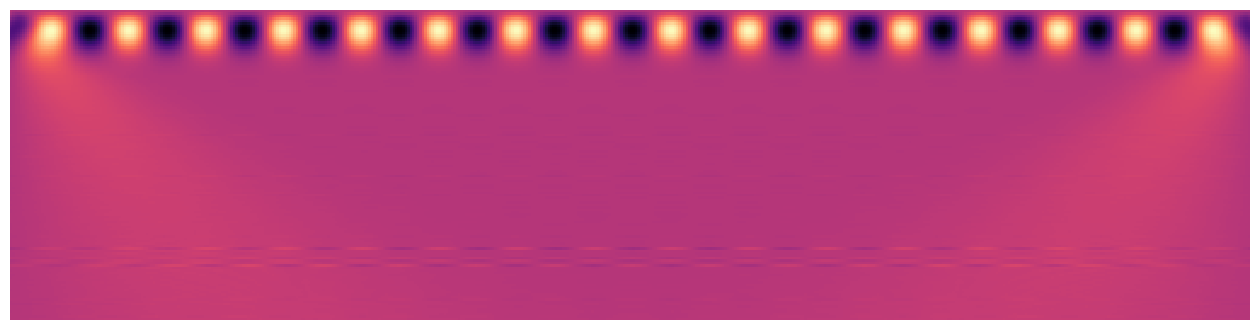

In [3]:
x = np.arange(512)
y = np.sin(2*np.pi*x/32)
coef, freqs=pywt.cwt(y,np.arange(1,129),'gaus1')
plt.matshow(coef) 
plt.set_cmap('magma')
plt.axis('off')
plt.show() 

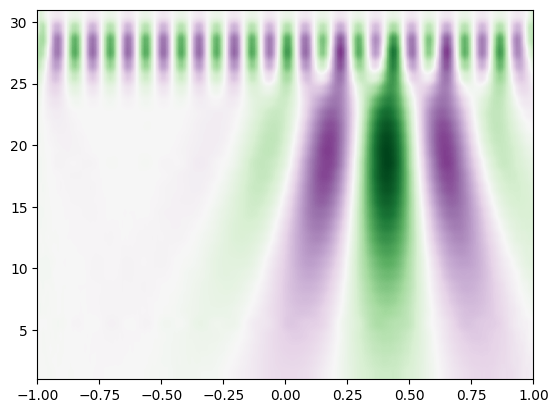

In [4]:
t = np.linspace(-1, 1, 200, endpoint=False)
sig  = np.cos(2 * np.pi * 7 * t) + np.real(np.exp(-7*(t-0.4)**2)*np.exp(1j*2*np.pi*2*(t-0.4)))
widths = np.arange(1, 31)
cwtmatr, freqs = pywt.cwt(sig, widths, 'mexh')
plt.imshow(cwtmatr, extent=[-1, 1, 1, 31], cmap='PRGn', aspect='auto',
           vmax=abs(cwtmatr).max(), vmin=-abs(cwtmatr).max())  
plt.show() 

In [5]:
wavlist = pywt.wavelist(kind='continuous')
print(f'continuous wavelets:\n{wavlist}')

continuous wavelets:
['cgau1', 'cgau2', 'cgau3', 'cgau4', 'cgau5', 'cgau6', 'cgau7', 'cgau8', 'cmor', 'fbsp', 'gaus1', 'gaus2', 'gaus3', 'gaus4', 'gaus5', 'gaus6', 'gaus7', 'gaus8', 'mexh', 'morl', 'shan']


In [6]:
WAV_NAME = 'cmor1.5-1.0'
dt = 0.01  # 100 Hz sampling
frequencies = pywt.scale2frequency(WAV_NAME, [1, 2, 3, 4]) / dt
print(f'100Hz freq: {frequencies}')

sr = 22050  # 22050 Hz sampling
dt = 1 / sr
print(f'{sr} sample rate - dt: {dt}')
frequencies = pywt.scale2frequency(WAV_NAME, [1, 2, 3, 4]) / dt
print(f'{sr}Hz freq: {frequencies}')

100Hz freq: [100.          50.          33.33333333  25.        ]
22050 sample rate - dt: 4.5351473922902495e-05
22050Hz freq: [22050.  11025.   7350.   5512.5]


In [7]:
fs = 1 / dt
frequencies = frequencies / fs # normalize
print(f'nomailized freq:\n{frequencies}')
scale = pywt.frequency2scale(WAV_NAME, frequencies)
scale

nomailized freq:
[1.         0.5        0.33333333 0.25      ]


array([1., 2., 3., 4.])

Continuous wavelet will be evaluated over the range [-8.0, 8.0]
wavelet cmor1.5-1.0 central freq is 1.0


Text(0.5, 1.0, '|FFT(filter)|$^2$')

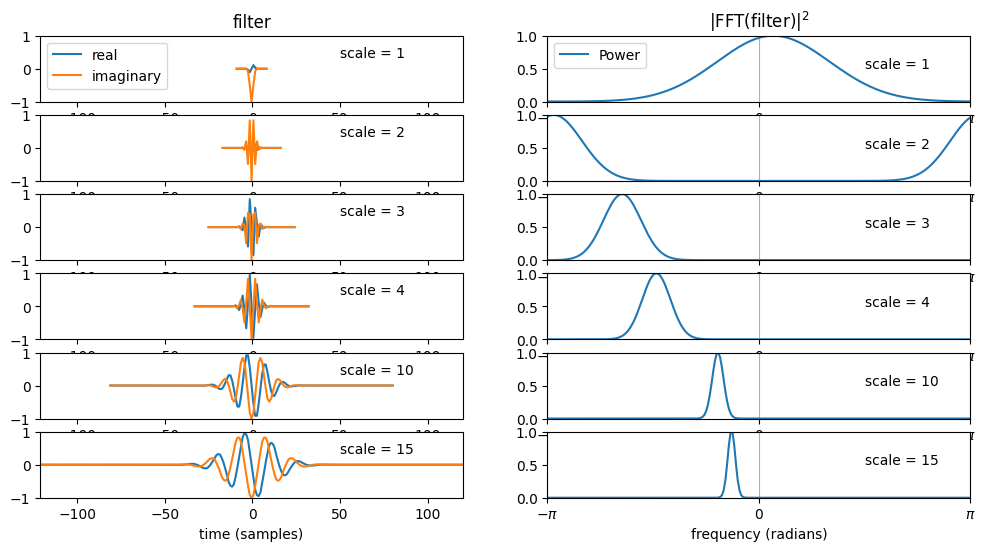

In [8]:
wav = pywt.ContinuousWavelet(WAV_NAME)

# print the range over which the wavelet will be evaluated
print("Continuous wavelet will be evaluated over the range [{}, {}]".format(
    wav.lower_bound, wav.upper_bound))
print(f'wavelet {WAV_NAME} central freq is {pywt.central_frequency(WAV_NAME)}')

width = wav.upper_bound - wav.lower_bound

scales = [1, 2, 3, 4, 10, 15]

max_len = int(np.max(scales)*width + 1)
t = np.arange(max_len)
fig, axes = plt.subplots(len(scales), 2, figsize=(12, 6))
for n, scale in enumerate(scales):
    # The following code is adapted from the internals of cwt
    int_psi, x = pywt.integrate_wavelet(wav, precision=10)
    step = x[1] - x[0]
    j = np.floor(
        np.arange(scale * width + 1) / (scale * step))
    if np.max(j) >= np.size(int_psi):
        j = np.delete(j, np.where((j >= np.size(int_psi)))[0])
    j = j.astype(np.int_)

    # normalize int_psi for easier plotting
    int_psi /= np.abs(int_psi).max()

    # discrete samples of the integrated wavelet
    filt = int_psi[j][::-1]

    # The CWT consists of convolution of filt with the signal at this scale
    # Here we plot this discrete convolution kernel at each scale.

    nt = len(filt)
    t = np.linspace(-nt//2, nt//2, nt)
    axes[n, 0].plot(t, filt.real, t, filt.imag)
    axes[n, 0].set_xlim([-max_len//2, max_len//2])
    axes[n, 0].set_ylim([-1, 1])
    axes[n, 0].text(50, 0.35, 'scale = {}'.format(scale))

    f = np.linspace(-np.pi, np.pi, max_len)
    filt_fft = np.fft.fftshift(np.fft.fft(filt, n=max_len))
    filt_fft /= np.abs(filt_fft).max()
    axes[n, 1].plot(f, np.abs(filt_fft)**2)
    axes[n, 1].set_xlim([-np.pi, np.pi])
    axes[n, 1].set_ylim([0, 1])
    axes[n, 1].set_xticks([-np.pi, 0, np.pi])
    axes[n, 1].set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    axes[n, 1].grid(True, axis='x')
    axes[n, 1].text(np.pi/2, 0.5, 'scale = {}'.format(scale))

axes[n, 0].set_xlabel('time (samples)')
axes[n, 1].set_xlabel('frequency (radians)')
axes[0, 0].legend(['real', 'imaginary'], loc='upper left')
axes[0, 1].legend(['Power'], loc='upper left')
axes[0, 0].set_title('filter')
axes[0, 1].set_title(r'|FFT(filter)|$^2$')

In [9]:

def calc_scales(totalscal: int=256, wavename: str='cmor3-3'):
    fc = pywt.central_frequency(wavename)
    print(f'wavelet [{wavename}] central freq: {fc}')
    cparam = 2 * fc * totalscal
    print(f'cparam: {cparam}')
    tmp = np.arange(totalscal, 1, -1)
    print(f'total scales range:\n{tmp}')
    scales = cparam / tmp
    return scales


In [10]:
scales = calc_scales(32, 'cmor3-1')
print(scales)

wavelet [cmor3-1] central freq: 1.0
cparam: 64.0
total scales range:
[32 31 30 29 28 27 26 25 24 23 22 21 20 19 18 17 16 15 14 13 12 11 10  9
  8  7  6  5  4  3  2]
[ 2.          2.06451613  2.13333333  2.20689655  2.28571429  2.37037037
  2.46153846  2.56        2.66666667  2.7826087   2.90909091  3.04761905
  3.2         3.36842105  3.55555556  3.76470588  4.          4.26666667
  4.57142857  4.92307692  5.33333333  5.81818182  6.4         7.11111111
  8.          9.14285714 10.66666667 12.8        16.         21.33333333
 32.        ]


In [11]:
from cwt import getDefaultScales

s0, ds, wavscales = getDefaultScales(1691136, 1/12, sr, low_freq=40)
print(f's0: {s0}')
print(f'ds: {ds}')
print(wavscales)

s0: 2
ds: 0.08333333333333333
[  2.           2.11892619   2.2449241    2.37841423   2.5198421
   2.66967971   2.82842712   2.99661415   3.1748021    3.36358566
   3.56359487   3.77549725   4.           4.23785238   4.48984819
   4.75682846   5.0396842    5.33935942   5.65685425   5.99322831
   6.34960421   6.72717132   7.12718975   7.5509945    8.
   8.47570475   8.97969639   9.51365692  10.0793684   10.67871883
  11.3137085   11.98645662  12.69920842  13.45434264  14.25437949
  15.101989    16.          16.95140951  17.95939277  19.02731384
  20.1587368   21.35743767  22.627417    23.97291323  25.39841683
  26.90868529  28.50875898  30.20397801  32.          33.90281902
  35.91878555  38.05462768  40.3174736   42.71487533  45.254834
  47.94582646  50.79683366  53.81737058  57.01751796  60.40795601
  64.          67.80563804  71.83757109  76.10925536  80.63494719
  85.42975067  90.50966799  95.89165292 101.59366733 107.63474115
 114.03503592 120.81591202 128.         135.61127608 143.